#
Total sales


In [8]:
import pandas as pd

# 1. Load the dataset into this specific file
data = pd.read_csv(r"C:\Users\sumit\Downloads\archive (3)\Sample - Superstore.csv", encoding="windows-1252")

# 2. Calculate the total sales
total_sales = data['Sales'].sum()

# 3. Print the result
print(f'Total Sales: ${total_sales:,.2f}')

Total Sales: $2,297,200.86


Total profit


In [7]:
total_profit = data['Profit'].sum()
print(f'Total Profit: ${total_profit:,.2f}')

Total Profit: $286,397.02


Which product sells the most?

In [9]:
# Top product by Total Revenue ($)
top_revenue = data.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).reset_index()
top_revenue.head(1)

,Product Name,Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824


Which category performs best?

In [12]:
# Group by Category and calculate key performance metrics
category_perf = data.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum')
).reset_index()

# Calculate Profit Margin percentage
category_perf['Profit_Margin_%'] = (category_perf['Total_Profit'] / category_perf['Total_Sales']) * 100

# Sort by Total Profit descending
category_perf = category_perf.sort_values(by='Total_Profit', ascending=False)
print(category_perf)

          Category  Total_Sales  Total_Profit  Total_Quantity  Profit_Margin_%
2       Technology  836154.0330   145454.9481            6939        17.395712
1  Office Supplies  719047.0320   122490.8008           22906        17.035158
0        Furniture  741999.7953    18451.2728            8028         2.486695


Which month has the highest sales?
Which month has the highest profit?

In [14]:
import pandas as pd

# 1. Ensure Order Date is in datetime format
data['Order Date'] = pd.to_datetime(data['Order Date'])

# --- OPTION A: Aggregated by Month Name (All Years Combined) ---
# Extract month name
data['Month_Name'] = data['Order Date'].dt.month_name()

# Group by Month and sum Sales & Profit
monthly_overall = data.groupby('Month_Name')[['Sales', 'Profit']].sum()

# Highest Sales & Highest Profit overall
top_sales_month = monthly_overall['Sales'].idxmax()
top_profit_month = monthly_overall['Profit'].idxmax()

print("--- Overall Seasonal Monthly Peak (All Years) ---")
print(f"Highest Sales Month: {top_sales_month} (${monthly_overall.loc[top_sales_month, 'Sales']:,.2f})")
print(f"Highest Profit Month: {top_profit_month} (${monthly_overall.loc[top_profit_month, 'Profit']:,.2f})")

# --- OPTION B: By Specific Month & Year (e.g., Nov 2017) ---
data['Year_Month'] = data['Order Date'].dt.to_period('M')
monthly_trend = data.groupby('Year_Month')[['Sales', 'Profit']].sum()

print("\n--- Absolute Single Highest Month in History ---")
print(f"Highest Sales Month-Year: {monthly_trend['Sales'].idxmax()} (${monthly_trend['Sales'].max():,.2f})")
print(f"Highest Profit Month-Year: {monthly_trend['Profit'].idxmax()} (${monthly_trend['Profit'].max():,.2f})")

--- Overall Seasonal Monthly Peak (All Years) ---
Highest Sales Month: November ($352,461.07)
Highest Profit Month: December ($43,369.19)

--- Absolute Single Highest Month in History ---
Highest Sales Month-Year: 2017-11 ($118,447.82)
Highest Profit Month-Year: 2016-12 ($17,885.31)


In [15]:
# 1. Calculate Pearson correlation between Discount and Profit
correlation = data['Discount'].corr(data['Profit'])
print(f"Correlation between Discount and Profit: {correlation:.4f}")

# 2. See Average and Total Profit for each Discount level
discount_breakdown = data.groupby('Discount').agg(
    Average_Profit=('Profit', 'mean'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Row ID', 'count')
).reset_index()

print(discount_breakdown)

Correlation between Discount and Profit: -0.2195
    Discount  Average_Profit  Total_Profit  Total_Orders
0       0.00       66.900292   320987.6032          4798
1       0.10       96.055074     9029.1770            94
2       0.15       27.288298     1418.9915            52
3       0.20       24.702572    90337.3060          3657
4       0.30      -45.679636   -10369.2774           227
5       0.32      -88.560656    -2391.1377            27
6       0.40     -111.927429   -23057.0504           206
7       0.45     -226.646464    -2493.1111            11
8       0.50     -310.703456   -20506.4281            66
9       0.60      -43.077212    -5944.6552           138
10      0.70      -95.874060   -40075.3569           418
11      0.80     -101.796797   -30539.0392           300


Which region generates the most sales/profit?

In [16]:
region_perf = data.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Row ID', 'count')
).reset_index()
print(region_perf)

    Region  Total_Sales  Total_Profit  Total_Orders
0  Central  501239.8908    39706.3625          2323
1     East  678781.2400    91522.7800          2848
2    South  391721.9050    46749.4303          1620
3     West  725457.8245   108418.4489          3203


In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set global Seaborn visual style
sns.set_theme(style="whitegrid")

# Ensure 'Order Date' is converted to datetime
data['Order Date'] = pd.to_datetime(data['Order Date'])

1. 📈 Monthly Sales & 2. 📈 Monthly Profit

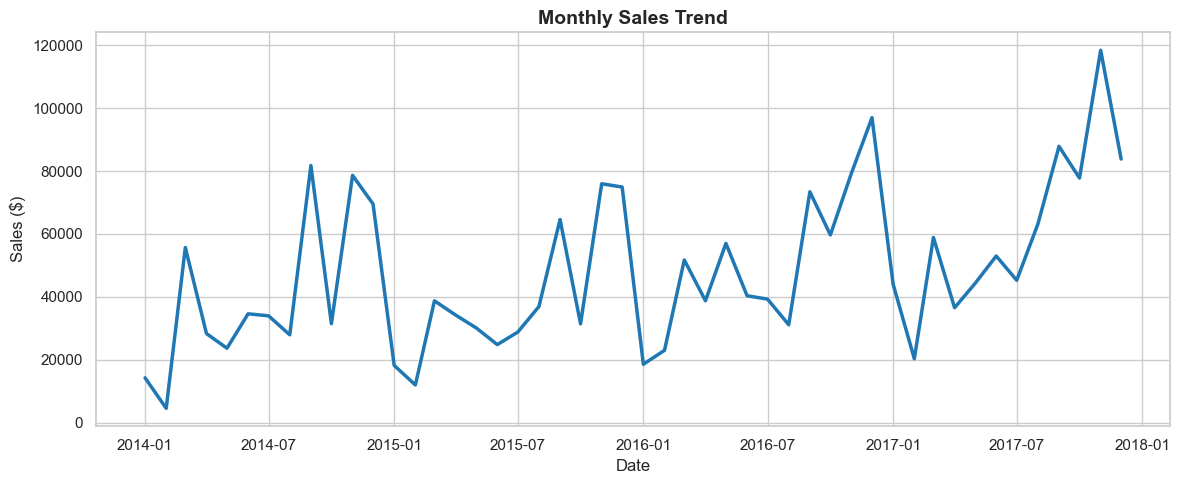

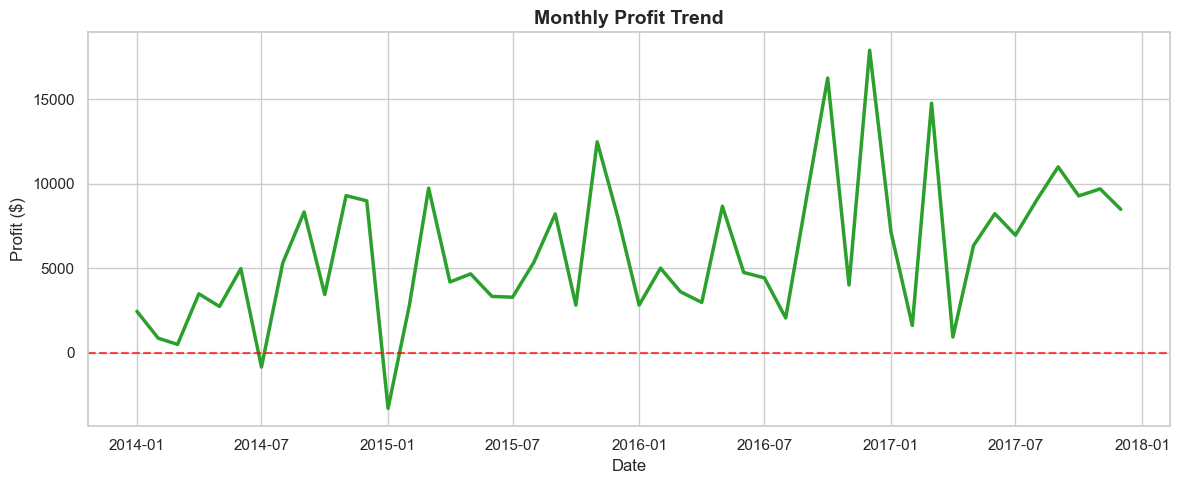

In [18]:
# Create Year-Month column
data['Year_Month'] = data['Order Date'].dt.to_period('M').dt.to_timestamp()

# Aggregate monthly
monthly_df = (
    data.groupby('Year_Month')[['Sales', 'Profit']].sum().reset_index()
)

# 1. Monthly Sales Line Plot
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_df, x='Year_Month', y='Sales', color='#1f77b4', linewidth=2.5
)
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()

# 2. Monthly Profit Line Plot
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_df, x='Year_Month', y='Profit', color='#2ca02c', linewidth=2.5
)
plt.axhline(
    0, color='red', linestyle='--', alpha=0.7
)  # Reference line for zero profit
plt.title('Monthly Profit Trend', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.show()

3. 📊 Sales by Category & 4. 📊 Profit by Category

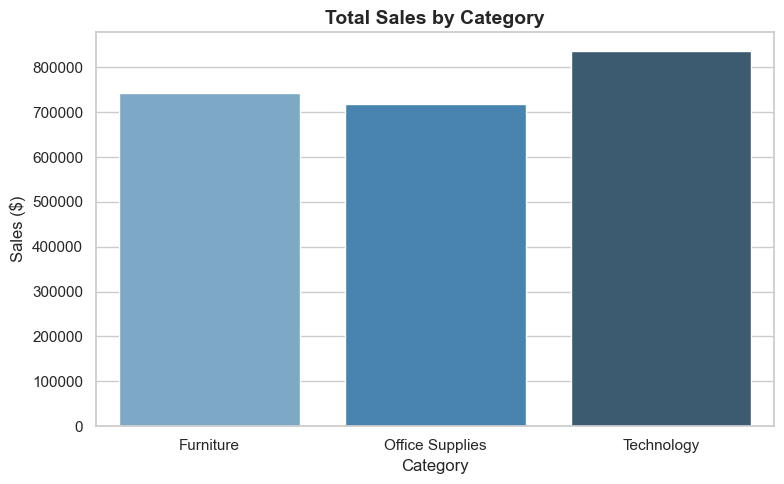

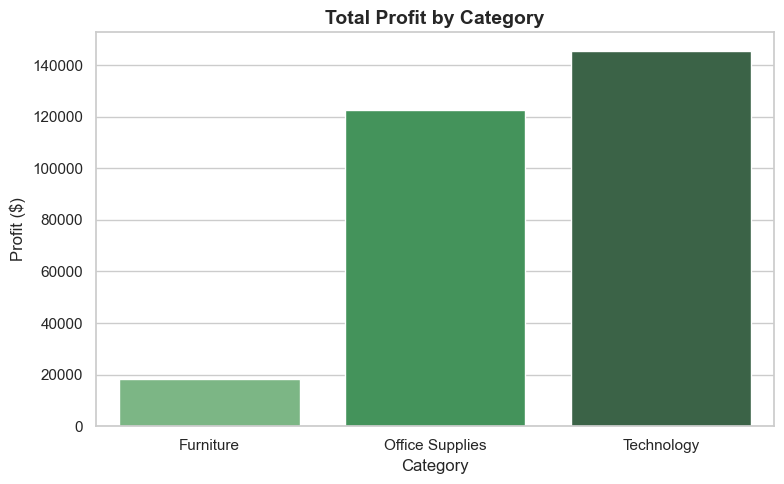

In [32]:
category_df = (
    data.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
)

# 3. Sales by Category
plt.figure(figsize=(8, 5))
sns.barplot(
    data=category_df,
    x='Category',
    y='Sales',
    hue='Category',
    palette='Blues_d',
    legend=False,
)
plt.title('Total Sales by Category', fontsize=14, fontweight='bold')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()

# 4. Profit by Category
plt.figure(figsize=(8, 5))
sns.barplot(
    data=category_df,
    x='Category',
    y='Profit',
    hue='Category',
    palette='Greens_d',
    legend=False,
)
plt.title('Total Profit by Category', fontsize=14, fontweight='bold')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.show()

📊 Top 10 Products

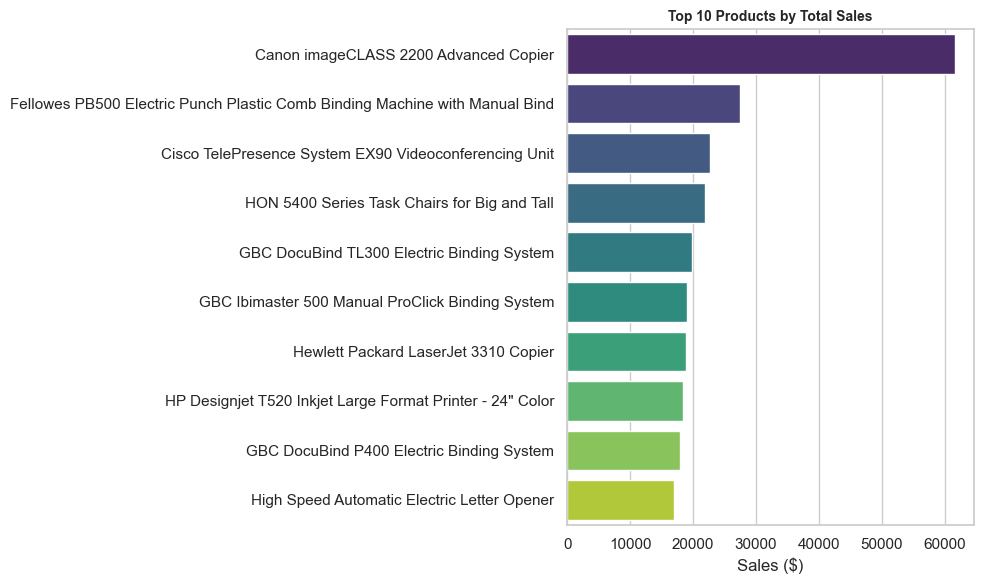

In [34]:
# Get Top 10 Products by Sales
top10_products = (
    data.groupby('Product Name')['Sales'].sum().nlargest(10).reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10_products,
    x='Sales',
    y='Product Name',
    hue='Product Name',
    palette='viridis',
    legend=False,
)
plt.title('Top 10 Products by Total Sales', fontsize=10, fontweight='bold')
plt.xlabel('Sales ($)')
plt.ylabel('')
plt.tight_layout()
plt.show()

Regional Performance

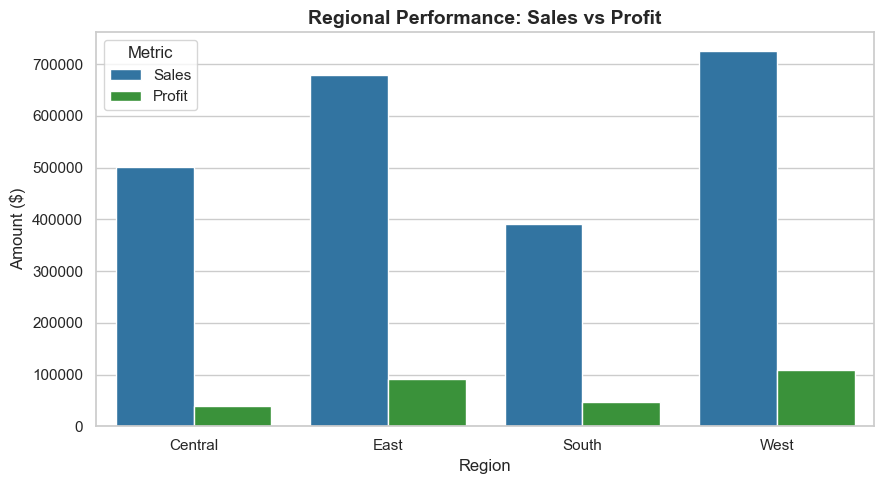

In [23]:
region_df = data.groupby('Region')[['Sales', 'Profit']].sum().reset_index()

# Reshape data with the corrected parameter (value_name)
region_melted = pd.melt(
    region_df,
    id_vars=['Region'],
    value_vars=['Sales', 'Profit'],
    var_name='Metric',
    value_name='Amount'
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=region_melted,
    x='Region',
    y='Amount',
    hue='Metric',
    palette=['#1f77b4', '#2ca02c']
)
plt.title('Regional Performance: Sales vs Profit', fontsize=14, fontweight='bold')
plt.ylabel('Amount ($)')
plt.tight_layout()
plt.show()

🔵 Discount vs Profit

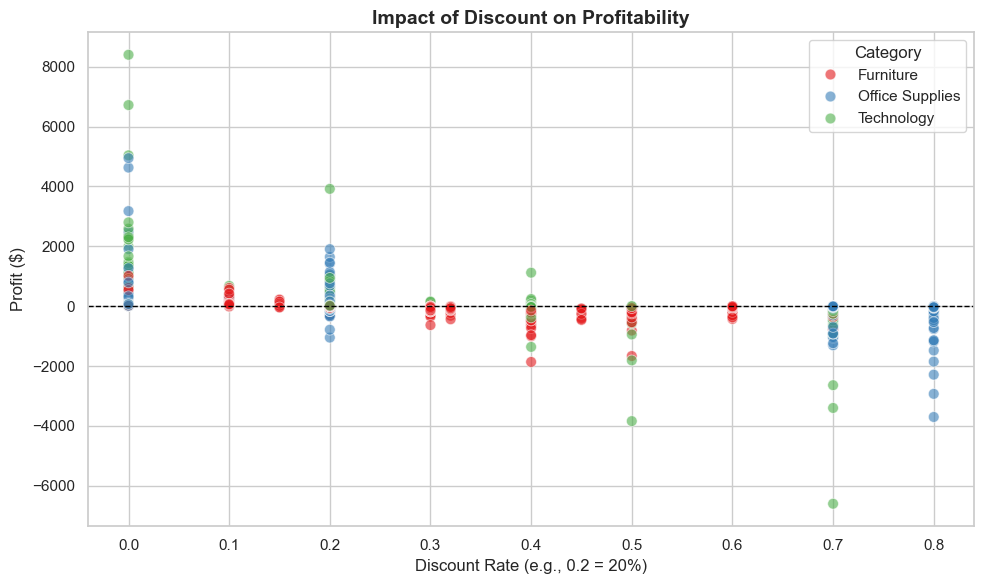

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data,
    x='Discount',
    y='Profit',
    hue='Category',
    alpha=0.6,
    s=60,
    palette='Set1',
)
plt.axhline(
    0, color='black', linestyle='--', linewidth=1
)  # Break-even line at $0
plt.title(
    'Impact of Discount on Profitability', fontsize=14, fontweight='bold'
)
plt.xlabel('Discount Rate (e.g., 0.2 = 20%)')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.show()